# Dual Thrust 策略回测

## 策略说明

Dual Thrust 是经典的日内交易策略，由 Mike Shaoyan 开发。

### 核心原理
- **波动区间**: 昨日最高价(HH) - 昨日最低价(LC)
- **上轨**: 昨日收盘价(HC) + K × 波动区间
- **下轨**: 昨日收盘价(HC) - K × 波动区间

### 本策略实现（适配 A 股 T+1）
- **买入**: 每日尾盘 14:50-14:55 买入
- **卖出**: 次日早盘 9:31-10:00 卖出
- **过滤**: 60日均线向上 + 大市值（≥300亿）
- **止损/止盈**: 2% / 3%

In [1]:
%reload_ext autoreload
%autoreload 2
from my_utils.fun import *
from my_utils.trade_fun import *
import polars as pl
import pandas as pd
import datetime as dt
import time

logging = get_logger(log_file='Dual_Thrust策略回测.log', inherit=False)

# ==================== 1. 参数配置 ====================

In [2]:
start_date = dt.date(2024, 1, 1)
end_date = dt.datetime.today()

# Dual Thrust 参数
params_dict = {
    'k_long': 0.8,         # 做多系数
    'k_short': 0.8,        # 做空系数（策略只做多）
    'stop_loss_pct': 0.02, # 止损比例（2%）
    'profit_exit_pct': 0.03, # 止盈比例（3%）
    # 过滤条件
    'mv_min': 300,         # 最小自由流通市值（亿）- 至少300亿
    'mv_max': 3000,        # 最大自由流通市值（亿）
    'vol_min': 1e8,       # 最小成交量
}

logging.info(f"策略参数: {params_dict}")

策略参数: {'k_long': 0.8, 'k_short': 0.8, 'stop_loss_pct': 0.02, 'profit_exit_pct': 0.03, 'mv_min': 300, 'mv_max': 3000, 'vol_min': 100000000.0}


# ==================== 2. 数据加载 ====================

In [3]:
# 获取日线数据
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open', 'close', 'pre_close', 'limit_up', 'limit_down'])

# 获取市值数据
market_value = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_daily_basic')
market_value = market_value.with_columns([
   (pl.col('free_share') * pl.col('close') / 1e4).alias('free_float_mv')
])

# 合并数据
stock_data = stock_data.join(
    market_value.select(['code', 'trading_date', 'free_float_mv']),
    on=['code', 'trading_date'],
    how='left'
)

logging.info(f"数据加载完成，共 {stock_data.height} 条记录")

数据加载完成，共 2793103 条记录


# ==================== 3. Dual Thrust 特征计算 ====================

In [4]:
# 确保按股票和日期排序
stock_data = stock_data.sort(["code", "trading_date"])

# 计算60日均线（用于趋势过滤）
stock_data = add_sma(stock_data, window=60)

# 标记60日均线方向（前一日 < 当日 = 向上）
stock_data = stock_data.with_columns([
    (pl.col('sma_60') > pl.col('sma_60').shift(1).over('code')).alias('ma60_up'),
])

# 计算 Dual Thrust 上下轨（使用前一日数据）
# HH = 昨日最高价, HC = 昨日收盘价, LC = 昨日最低价
stock_data = stock_data.with_columns([
    pl.col('high').shift(1).over('code').alias('prev_high'),   # HH
    pl.col('close').shift(1).over('code').alias('prev_close'), # HC
    pl.col('low').shift(1).over('code').alias('prev_low'),    # LC
])

# 计算波动区间和上下轨
stock_data = stock_data.with_columns([
    # 波动区间
    (pl.col('prev_high') - pl.col('prev_low')).alias('range'),
    
    # 上轨：收盘价 + K * 波动区间
    (pl.col('prev_close') + params_dict['k_long'] * (pl.col('prev_high') - pl.col('prev_low'))).alias('upper_bound'),
    
    # 下轨：收盘价 - K * 波动区间
    (pl.col('prev_close') - params_dict['k_short'] * (pl.col('prev_high') - pl.col('prev_low'))).alias('lower_bound'),
])

logging.info("Dual Thrust 特征计算完成")

Dual Thrust 特征计算完成


# ==================== 4. 信号生成 ====================

In [5]:
# 生成买入信号
# 尾盘（14:50-14:55）价格突破上轨时产生信号
# 信号条件：
# 1. 收盘价在上轨附近（收盘价 >= 上轨 * 0.98，即突破上轨）
# 2. 60日均线向上
# 3. 非ST、非创业板、科创板
# 4. 市值 >= 300亿
# 5. 成交量过滤

stock_data = stock_data.with_columns(
    signal = pl.when(
        # 1. 价格突破上轨（收盘价在上轨附近或之上）
        (pl.col('close') >= pl.col('upper_bound') * 0.98) &
        
        # 2. 60日均线向上
        (pl.col('ma60_up') == True) &
        
        # 3. 非ST
        ~(pl.col('type').is_not_null() & (pl.col('type') == 'ST')) &
        
        # 4. 非创业板、科创板
        ~(pl.col('code').str.split('.').list[1].str.starts_with('30') | 
          pl.col('code').str.split('.').list[1].str.starts_with('688')) &
        
        # 5. 市值过滤（>= 300亿）
        (pl.col('free_float_mv') >= params_dict['mv_min']) & 
        (pl.col('free_float_mv') <= params_dict['mv_max']) &
        
        # 6. 成交量过滤
        (pl.col('volume') * pl.col('close') >= params_dict['vol_min']) &
        
        # 7. 确保上下轨和均线数据存在
        (pl.col('upper_bound').is_not_null()) &
        (pl.col('lower_bound').is_not_null()) &
        (pl.col('sma_60').is_not_null())
    ).then(1).otherwise(0)
)

# 筛选出买入信号
信号文件 = stock_data.filter(pl.col('signal') == 1)

logging.info(f"生成买入信号 {信号文件.height} 个")

生成买入信号 393 个


## Dual Thrust 交易函数（隔夜策略 - 适配15分钟数据）

- **买入**: 尾盘最后一根15分钟K线（14:45-15:00）收盘价买入
- **卖出**: 次日早盘第一根15分钟K线（9:30-9:45）开盘价卖出
- **止损**: 亏损 2% 时卖出
- **止盈**: 盈利 3% 时卖出
- **持有时间**: 约 16 小时（隔夜）

**15分钟数据时间点映射**：
- 尾盘买入 → 14:45-15:00 这根K线（hour=14, minute=45）
- 次日早盘卖出 → 9:30-9:45 这根K线（hour=9, minute=30）

In [6]:
def dual_thrust_trade(code_list, trade_date: dt.date, fee_rate=0.004, need_adj=True,
                       stop_loss_pct=0.02, profit_exit_pct=0.03):
    """
    Dual Thrust 隔夜策略交易函数（适配15分钟数据）

    买入：尾盘最后一根15分钟K线（14:45-15:00）收盘价买入
    卖出：次日早盘第一根15分钟K线（9:30-9:45）开盘价卖出

    止损/止盈：在持有期间如触发则提前平仓
    """
    import time as Time
    from datetime import timedelta

    start_process_time = Time.time()
    # 扩大历史数据范围，确保能获取到前一个交易日的数据（处理假日、长假等情况）
    hist_start_date = trade_date - timedelta(days=15)
    end_date = trade_date + timedelta(days=5)

    result = []

    for code in code_list:
        try:
            # ===== 1. 获取15分钟线数据 =====
            mins_data = read_min_data(trade_date, end_date, [code])
            mins_data = mins_data.sort('datetime')

            if mins_data.height == 0:
                continue

            # ===== 2. 获取日线数据（扩大历史范围，确保能获取前一交易日数据）=====
            daily_data = read_day_data(hist_start_date, end_date, [code], file_path='ts_stock_all_data')

            # 获取复权因子
            if need_adj:
                adj_data = read_day_data(hist_start_date, end_date, [code], file_path='ts_adj')
                if adj_data.height > 0:
                    daily_data = daily_data.join(
                        adj_data[['trading_date', 'code', 'adj_factor']],
                        on=['trading_date', 'code'],
                        how='left',
                    )
                    daily_data = daily_data.rename({'adj_factor': 'adj'})

            # 获取前一日数据用于计算上下轨（处理假日情况：向前找最近的有效交易日）
            prev_day = trade_date - timedelta(days=1)
            prev_daily = daily_data.filter(pl.col('trading_date') == prev_day)

            # 如果 prev_day 是假日，从 daily_data 中找最近的有效交易日
            if prev_daily.height == 0:
                available_days = daily_data.filter(
                    pl.col('trading_date') < trade_date
                ).sort('trading_date', descending=True)

                if available_days.height == 0:
                    continue
                prev_daily = available_days.head(1)

            prev_high = prev_daily['high'][0]
            prev_close = prev_daily['close'][0]
            prev_low = prev_daily['low'][0]
            prev_adj = prev_daily['adj'][0] if 'adj' in prev_daily.columns else 1

            # 计算上下轨
            range_val = prev_high - prev_low
            upper_bound = prev_close + params_dict['k_long'] * range_val
            lower_bound = prev_close - params_dict['k_short'] * range_val

            # ===== 3. 尾盘买入（14:45-15:00 最后一根15分钟K线）=====
            # 获取当日分钟数据
            day_mins = mins_data.filter(pl.col('trading_date') == trade_date)
            if day_mins.height == 0:
                continue

            # 寻找尾盘买入时机：14:45-15:00 的K线（hour=14, minute=45）
            buy_data = day_mins.filter(
                (pl.col('datetime').dt.hour() == 14) &
                (pl.col('datetime').dt.minute() == 45)
            )

            buy_price = None
            buy_time = None
            buy_adj = None

            if buy_data.height > 0:
                close_price = buy_data['close'][0]
                current_adj = buy_data['adj'][0] if 'adj' in buy_data.columns else 1
                # 价格突破上轨
                if close_price >= upper_bound * 0.98:
                    buy_price = close_price
                    buy_time = buy_data['datetime'][0]
                    buy_adj = current_adj

            # 如果14:45没有信号，尝试当日的任意尾盘时间点
            if buy_price is None:
                for row in day_mins.iter_rows(named=True):
                    current_hour = row['datetime'].hour
                    current_minute = row['datetime'].minute
                    # 找14:30之后的K线
                    if current_hour == 14 and current_minute >= 30:
                        if row['close'] >= upper_bound * 0.98:
                            buy_price = row['close']
                            buy_time = row['datetime']
                            buy_adj = row.get('adj', 1)
                            break
                    elif current_hour > 14:
                        if row['close'] >= upper_bound * 0.98:
                            buy_price = row['close']
                            buy_time = row['datetime']
                            buy_adj = row.get('adj', 1)
                            break

            if buy_price is None:
                continue

            # ===== 4. 次日早盘卖出（9:30-9:45 第一根15分钟K线）=====
            # 获取次日数据
            next_day = trade_date + timedelta(days=1)
            next_day_mins = mins_data.filter(pl.col('trading_date') == next_day)

            sell_price = None
            sell_time = None
            sell_reason = None
            sell_adj = buy_adj

            if next_day_mins.height > 0:
                # 早盘第一根K线：9:30-9:45（hour=9, minute=30）
                sell_data = next_day_mins.filter(
                    (pl.col('datetime').dt.hour() == 9) &
                    (pl.col('datetime').dt.minute() == 30)
                )

                if sell_data.height > 0:
                    # 检查止损/止盈
                    open_price = sell_data['open'][0]
                    current_adj = sell_data['adj'][0] if 'adj' in sell_data.columns else 1

                    # 1. 止损检查
                    if open_price <= buy_price * (1 - stop_loss_pct):
                        sell_price = open_price
                        sell_time = sell_data['datetime'][0]
                        sell_reason = '止损'
                        sell_adj = current_adj

                    # 2. 止盈检查
                    elif open_price >= buy_price * (1 + profit_exit_pct):
                        sell_price = open_price
                        sell_time = sell_data['datetime'][0]
                        sell_reason = '止盈'
                        sell_adj = current_adj

                    # 3. 正常卖出：早盘开盘价卖出
                    else:
                        sell_price = open_price
                        sell_time = sell_data['datetime'][0]
                        sell_reason = '早盘卖出'
                        sell_adj = current_adj
                else:
                    # 如果没有9:30的K线，尝试9:45
                    sell_data = next_day_mins.filter(
                        (pl.col('datetime').dt.hour() == 9) &
                        (pl.col('datetime').dt.minute() == 45)
                    )
                    if sell_data.height > 0:
                        open_price = sell_data['open'][0]
                        current_adj = sell_data['adj'][0] if 'adj' in sell_data.columns else 1

                        if open_price <= buy_price * (1 - stop_loss_pct):
                            sell_price = open_price
                            sell_time = sell_data['datetime'][0]
                            sell_reason = '止损'
                            sell_adj = current_adj
                        elif open_price >= buy_price * (1 + profit_exit_pct):
                            sell_price = open_price
                            sell_time = sell_data['datetime'][0]
                            sell_reason = '止盈'
                            sell_adj = current_adj
                        else:
                            sell_price = open_price
                            sell_time = sell_data['datetime'][0]
                            sell_reason = '早盘卖出'
                            sell_adj = current_adj

            # 如果没有找到卖出信号，用收盘价
            if sell_price is None:
                if next_day_mins.height > 0:
                    last_row = next_day_mins[-1]
                    sell_price = last_row['close']
                    sell_time = last_row['datetime']
                    sell_reason = '尾盘卖出'
                    sell_adj = last_row.get('adj', buy_adj)
                else:
                    # 没有次日数据，跳过
                    continue

            # ===== 5. 计算收益 =====
            buy_price_fee = buy_price * buy_adj * (1 + fee_rate)
            sell_price_fee = sell_price * sell_adj * (1 - fee_rate)
            profit = (sell_price_fee - buy_price_fee) / buy_price_fee * 100

            # 计算持有天数
            holding_days = 1 if sell_time.date() > trade_date else 0.5

            trade_info = {
                'code': code,
                'buy_time': buy_time,
                'buy_price': buy_price,
                'sell_time': sell_time,
                'sell_price': sell_price,
                'profit': profit,
                'holding_days': holding_days,
                'sell_reason': sell_reason
            }
            result.append(trade_info)

        except Exception as e:
            logging.info(f"处理 {code} 时出错: {str(e)}")
            continue

    return result

# ==================== 5. 运行回测 ====================

In [7]:
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

logging.info(f"回测时间区间: {start_date_str} 至 {end_date_str}")
logging.info(f"买入信号数量: {信号文件.height}")

# 定义带参数的交易函数
from functools import partial
trade_func = partial(
    dual_thrust_trade,
    stop_loss_pct=params_dict['stop_loss_pct'],
    profit_exit_pct=params_dict['profit_exit_pct']
)

# 运行回测
result_df, merged_df = cal_trade_info(
    信号文件,
    trade_fun=trade_func,
    start_date=start_date_str,
    end_date=end_date_str
)

回测时间区间: 2024-01-01 至 2026-04-21
买入信号数量: 393
使用40个进程并行处理，共169个日期任务
回测任务进度: 100%|███████████████████████| 169/169 [00:14<00:00, 11.46个日期/s]
所有回测任务完成，共处理132个日期的结果


# ==================== 6. 回测结果分析 ====================

卖出原因统计:
shape: (4, 2)
┌─────────────┬──────┐
│ sell_reason ┆ code │
│ ---         ┆ ---  │
│ str         ┆ u32  │
╞═════════════╪══════╡
│ 早盘卖出    ┆ 205  │
│ 止损        ┆ 76   │
│ null        ┆ 82   │
│ 止盈        ┆ 30   │
└─────────────┴──────┘
Dual Thrust 策略回测结果:

回测时间:2024-01-02 - 2026-04-20
策略胜率: 27.01%
策略盈亏比: 0.93
每日平均开仓个数: 2.36
平均持仓天数: 1.00 天
每单位风险期望收益:-0.4777
策略总收益率: -47.50%
策略年化收益率: -24.45%
最大回撤: -47.85%
最大回撤阶段: 2024-01-02 至 2026-03-18
夏普比率: -4.14
策略超额年化收益率: -39.42%
最终净值: 0.5250


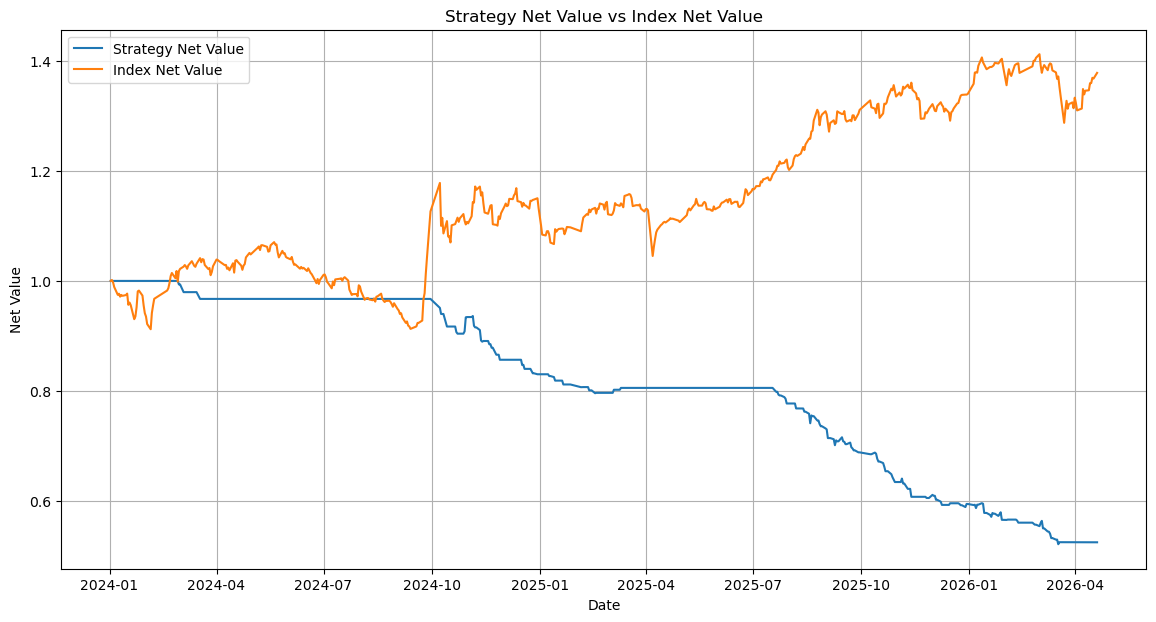

In [8]:
# 添加仓位权重
merged_df = merged_df.with_columns(
    pl.lit(0.4).alias('weight'),  # 单只股票最大仓位40%
    (pl.col('profit') * 0.4).alias('weight_profit')
)

# 统计卖出原因
if 'sell_reason' in merged_df.columns:
    logging.info('卖出原因统计:')
    reason_count = merged_df.group_by('sell_reason').agg(pl.count('code'))
    logging.info(reason_count)

# 生成回测报告
logging.info('=' * 50)
logging.info('Dual Thrust 策略回测结果:')
back_result = report_backtest_full(
    merged_df.to_pandas(),
    start_date=start_date_str,
    end_date=end_date_str,
    profit_col='weight_profit'
)

# ==================== 7. 真实资金回测 ====================

In [9]:
from my_backtester.my_backtester import Backtester

交割数据 = merged_df.to_pandas()

# 构建 orders
orders_list = []
for _, row in 交割数据.iterrows():
    if pd.isna(row['buy_time']) or pd.isna(row['sell_time']):
        continue
    
    buy_order = {
        'datetime': pd.to_datetime(row['buy_time']),
        'code': row['code'],
        'direction': 1,
        'price': row['buy_price'],
        'cash_ratio': row['weight'],
        'buy_time': row['buy_time'],
        'sell_time': row['sell_time'],
    }
    sell_order = {
        'datetime': pd.to_datetime(row['sell_time']),
        'code': row['code'],
        'direction': -1,
        'price': row['sell_price'],
        'cash_ratio': row['weight'],
        'buy_time': row['buy_time'],
        'sell_time': row['sell_time'],
    }
    orders_list.append(buy_order)
    orders_list.append(sell_order)

orders_df = pd.DataFrame(orders_list)

if len(orders_df) > 0:
    # 初始化回测引擎
    backtester = Backtester(
        orders=orders_df,
        initial_cash=10000000,
        commission=0.001,
        slippage=0.001
    )
    
    # 运行回测
    资金结果 = backtester.run(start_time=start_date_str, end_time=end_date_str)
    持仓结果 = backtester.pos_log
    交易记录 = backtester.trade_log
    
    # 汇报回测结果
    metrics_df, fig = backtester.report(return_method='compound', plot=True)
    fig.show()
else:
    logging.info('没有足够的交易数据进行真实资金回测')

c:\Users\20561\Desktop\策略\my_backtester\my_backtester.py:585: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

回测结果:
    指标名称                 指标值
  回测开始日期 2024-01-02 00:00:00
  回测结束日期 2026-04-07 00:00:00
    策略胜率              32.15%
   策略盈亏比                0.99
  策略总收益率             -35.15%
 策略年化收益率             -17.42%
    最大回撤             -35.85%
最大回撤开始日期 2024-01-02 00:00:00
最大回撤结束日期 2026-03-19 00:00:00
    夏普比率               -3.09
    最终净值              0.6485
